# Explainable Deep Learning for Multi-Class Skin Cancer Classification

## Thesis Project

### Dataset
- HAM10000 Skin Cancer Dataset

### Deep Learning Model
- EfficientNetB0 (Transfer Learning)

### Explainable AI
- Grad-CAM

### Objective
To develop an explainable deep learning framework for multi-class skin cancer classification using dermoscopic images.

In [3]:
import os
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

print("TensorFlow Version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow Version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
BASE_PATH = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"

metadata = pd.read_csv(
    os.path.join(BASE_PATH, "HAM10000_metadata.csv")
)

metadata.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [5]:
import glob
import os

image_dir1 = os.path.join(BASE_PATH, "HAM10000_images_part_1")
image_dir2 = os.path.join(BASE_PATH, "HAM10000_images_part_2")

image_paths = {}

for folder in [image_dir1, image_dir2]:
    for img in glob.glob(os.path.join(folder, "*.jpg")):
        image_id = os.path.splitext(os.path.basename(img))[0]
        image_paths[image_id] = img

metadata["image_path"] = metadata["image_id"].map(image_paths)

print("Total Images:", len(image_paths))
metadata[["image_id", "image_path"]].head()

Total Images: 10015


,image_id,image_path
0,ISIC_0027419,/kaggle/input/datasets/kmader/skin-cancer-mnis...
1,ISIC_0025030,/kaggle/input/datasets/kmader/skin-cancer-mnis...
2,ISIC_0026769,/kaggle/input/datasets/kmader/skin-cancer-mnis...
3,ISIC_0025661,/kaggle/input/datasets/kmader/skin-cancer-mnis...
4,ISIC_0031633,/kaggle/input/datasets/kmader/skin-cancer-mnis...


In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

metadata["label"] = label_encoder.fit_transform(metadata["dx"])

print("Label Mapping:")
print(dict(zip(label_encoder.classes_,
               label_encoder.transform(label_encoder.classes_))))

metadata[["image_id","dx","label"]].head()

Label Mapping:
{'akiec': np.int64(0), 'bcc': np.int64(1), 'bkl': np.int64(2), 'df': np.int64(3), 'mel': np.int64(4), 'nv': np.int64(5), 'vasc': np.int64(6)}


,image_id,dx,label
0,ISIC_0027419,bkl,2
1,ISIC_0025030,bkl,2
2,ISIC_0026769,bkl,2
3,ISIC_0025661,bkl,2
4,ISIC_0031633,bkl,2


In [7]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    metadata,
    test_size=0.20,
    stratify=metadata["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label"],
    random_state=42
)

print("Training :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))

Training : 8012
Validation : 1001
Test : 1002


In [9]:
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [10]:
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=True
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="image_path",
    y_col="label",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

Found 8012 validated image filenames.
Found 1001 validated image filenames.
Found 1002 validated image filenames.


In [11]:
images, labels = next(train_generator)

print(images.shape)
print(labels.shape)
print(labels[:10])

(32, 224, 224, 3)
(32,)
[5 3 5 1 5 4 5 2 5 4]


In [12]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

I0000 00:00:1785903840.595511      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785903840.601467      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [13]:
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.models import Model

x = base_model.output

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(512, activation="relu")(x)

x = Dropout(0.5)(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.3)(x)

output = Dense(7, activation="softmax")(x)

model = Model(
    inputs=base_model.input,
    outputs=output
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,843,690 (18.48 MB)

 Trainable params: 791,559 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [14]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [16]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=2,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "best_efficientnetb0.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [18]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["label"]),
    y=train_df["label"]
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.368593238822246), 1: np.float64(2.7848453249913105), 2: np.float64(1.3021290427433772), 3: np.float64(12.440993788819876), 4: np.float64(1.2860353130016051), 5: np.float64(0.21338020666879728), 6: np.float64(10.040100250626567)}


In [19]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/10


2026-08-05 04:25:45.708592: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:25:45.851874: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:25:46.195946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:25:46.336154: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:25:47.118549: E external/local_xla/xla/stream_

111/251 ━━━━━━━━━━━━━━━━━━━━ 1:32 660ms/step - accuracy: 0.1616 - loss: 2.5940

2026-08-05 04:27:14.494924: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:27:14.632445: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:27:14.953295: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:27:15.095497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:27:15.235979: E external/local_xla/xla/stream_

251/251 ━━━━━━━━━━━━━━━━━━━━ 0s 714ms/step - accuracy: 0.2088 - loss: 2.4186

2026-08-05 04:29:16.688590: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:29:16.824727: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:29:17.134492: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:29:17.274168: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:29:18.020193: E external/local_xla/xla/stream_

251/251 ━━━━━━━━━━━━━━━━━━━━ 236s 831ms/step - accuracy: 0.2710 - loss: 2.1735 - val_accuracy: 0.4895 - val_loss: 1.4753 - learning_rate: 1.0000e-04
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 124s 494ms/step - accuracy: 0.3776 - loss: 1.7254 - val_accuracy: 0.4855 - val_loss: 1.3636 - learning_rate: 1.0000e-04
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 124s 494ms/step - accuracy: 0.4154 - loss: 1.5587 - val_accuracy: 0.5055 - val_loss: 1.2516 - learning_rate: 1.0000e-04
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 124s 496ms/step - accuracy: 0.4483 - loss: 1.4142 - val_accuracy: 0.5574 - val_loss: 1.1735 - learning_rate: 1.0000e-04
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 125s 496ms/step - accuracy: 0.4744 - loss: 1.3469 - val_accuracy: 0.5514 - val_loss: 1.1461 - learning_rate: 1.0000e-04
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 124s 492ms/step - accuracy: 0.5114 - loss: 1.2682 - val_accuracy: 0.5435 - val_loss: 1.1662 - learning_rate: 1.0000e-04
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 125s 496ms/

In [20]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.5718 - loss: 1.0902

2026-08-05 04:48:24.217283: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:48:24.353290: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:48:24.671963: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:48:24.813228: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-05 04:48:25.585457: E external/local_xla/xla/stream_

32/32 ━━━━━━━━━━━━━━━━━━━━ 22s 686ms/step - accuracy: 0.5898 - loss: 1.0585
Test Accuracy: 0.589820384979248


In [21]:
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

print("Trainable Layers:",
      sum([layer.trainable for layer in base_model.layers]))

Trainable Layers: 30


In [24]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning model compiled!")

Fine-tuning model compiled!


In [25]:
history_finetune = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=5,
    class_weight=class_weights,
    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 178s 599ms/step - accuracy: 0.4462 - loss: 1.5679 - val_accuracy: 0.5125 - val_loss: 1.1829 - learning_rate: 1.0000e-05
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 126s 503ms/step - accuracy: 0.4385 - loss: 1.4731 - val_accuracy: 0.4985 - val_loss: 1.2105 - learning_rate: 1.0000e-05
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 126s 501ms/step - accuracy: 0.4480 - loss: 1.4396 - val_accuracy: 0.4955 - val_loss: 1.2151 - learning_rate: 2.0000e-06
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 126s 501ms/step - accuracy: 0.4307 - loss: 1.4692 - val_accuracy: 0.4985 - val_loss: 1.2235 - learning_rate: 2.0000e-06
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 127s 506ms/step - accuracy: 0.4423 - loss: 1.4222 - val_accuracy: 0.4955 - val_loss: 1.2233 - learning_rate: 1.0000e-06


## Fine-tuning Experiment

We performed fine-tuning by unfreezing the last 30 layers of EfficientNetB0 with a learning rate of 1e-5.

The validation accuracy decreased compared to the frozen model. Therefore, the frozen EfficientNetB0 model was selected as the final model for all experiments.

In [31]:
# Freeze all EfficientNet layers again
base_model.trainable = False

In [35]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [36]:
import os

print(os.listdir("/kaggle/working"))

['.virtual_documents', 'best_efficientnetb0.keras']


In [37]:
from tensorflow.keras.models import load_model

model = load_model("/kaggle/working/best_efficientnetb0.keras")

print("Best Model Loaded Successfully!")

Best Model Loaded Successfully!


In [38]:
test_loss, test_acc = model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 340ms/step - accuracy: 0.5898 - loss: 1.0585
Test Accuracy: 0.589820384979248


In [39]:
import numpy as np

# Take one image from test set
img, label = test_generator[0]

print("True Label:", label[0])

sample_image = img[0]
sample_label = label[0]

True Label: 5


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [3.0..201.0].


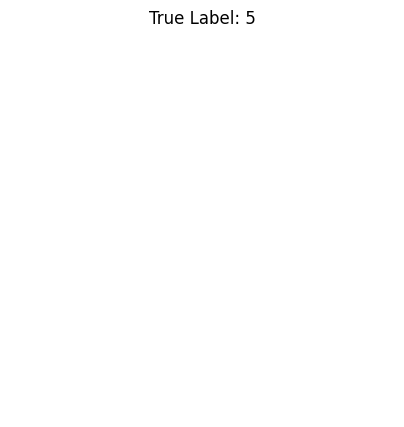

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.imshow(sample_image)
plt.title(f"True Label: {sample_label}")
plt.axis("off")
plt.show()

In [41]:
for layer in model.layers:
    print(layer.name)

input_layer
rescaling
normalization
rescaling_1
stem_conv_pad
stem_conv
stem_bn
stem_activation
block1a_dwconv
block1a_bn
block1a_activation
block1a_se_squeeze
block1a_se_reshape
block1a_se_reduce
block1a_se_expand
block1a_se_excite
block1a_project_conv
block1a_project_bn
block2a_expand_conv
block2a_expand_bn
block2a_expand_activation
block2a_dwconv_pad
block2a_dwconv
block2a_bn
block2a_activation
block2a_se_squeeze
block2a_se_reshape
block2a_se_reduce
block2a_se_expand
block2a_se_excite
block2a_project_conv
block2a_project_bn
block2b_expand_conv
block2b_expand_bn
block2b_expand_activation
block2b_dwconv
block2b_bn
block2b_activation
block2b_se_squeeze
block2b_se_reshape
block2b_se_reduce
block2b_se_expand
block2b_se_excite
block2b_project_conv
block2b_project_bn
block2b_drop
block2b_add
block3a_expand_conv
block3a_expand_bn
block3a_expand_activation
block3a_dwconv_pad
block3a_dwconv
block3a_bn
block3a_activation
block3a_se_squeeze
block3a_se_reshape
block3a_se_reduce
block3a_se_expand

In [45]:
import tensorflow as tf
import numpy as np

last_conv_layer_name = "top_conv"

grad_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=[
        model.get_layer(last_conv_layer_name).output,
        model.output
    ]
)

In [46]:
img_array = np.expand_dims(sample_image, axis=0)

with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)

    pred_index = tf.argmax(predictions[0])
    class_channel = predictions[:, pred_index]

grads = tape.gradient(class_channel, conv_outputs)

pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

conv_outputs = conv_outputs[0]

heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)

heatmap = tf.maximum(heatmap, 0)
heatmap = heatmap / tf.math.reduce_max(heatmap)

heatmap = heatmap.numpy()

print("Predicted Class:", pred_index.numpy())

Predicted Class: 5


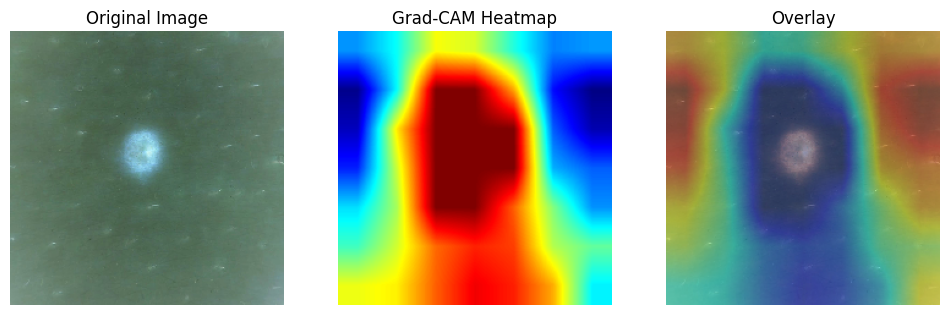

In [47]:
import cv2
import matplotlib.pyplot as plt

# Resize heatmap
heatmap = cv2.resize(heatmap, (224, 224))

# Convert heatmap to color
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

# Original image
img = sample_image.copy()

# Convert image back to uint8
img = np.uint8(img * 255)

# Overlay
superimposed_img = cv2.addWeighted(img, 0.6, heatmap, 0.4, 0)

# Show results
plt.figure(figsize=(12,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(heatmap)
plt.title("Grad-CAM Heatmap")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
plt.title("Overlay")
plt.axis("off")

plt.show()

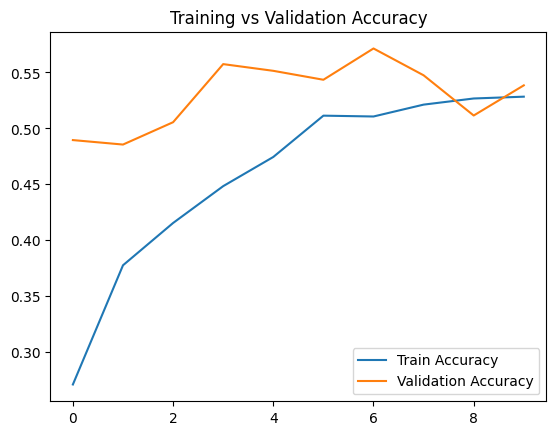

In [48]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")
plt.show()

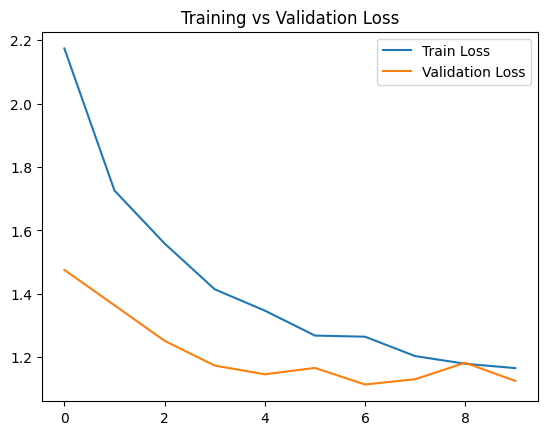

In [49]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

In [51]:
import numpy as np

pred = model.predict(test_generator)
pred_classes = np.argmax(pred, axis=1)

print(pred_classes[:10])

32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 397ms/step
[5 5 5 2 2 5 6 1 5 6]


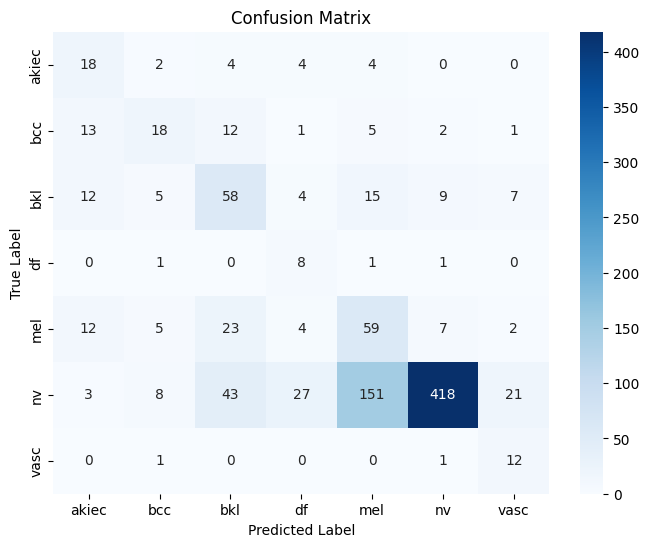

In [53]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(test_generator.labels, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

1. Introduction

2. Import Libraries

3. Load Dataset

4. Data Preprocessing

5. Label Encoding

6. Train Validation Test Split

7. Data Generator

8. Build EfficientNetB0

9. Compile Model

10. Train Model

11. Evaluate Model

12. Classification Report

13. Confusion Matrix

14. Accuracy & Loss Graph

15. Grad-CAM Visualization

16. Conclusion

In [54]:
model.save("/kaggle/working/final_skin_cancer_model.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [56]:
import shutil

shutil.copy(
    "/kaggle/working/final_skin_cancer_model.keras",
    "/kaggle/working/final_skin_cancer_model_backup.keras"
)

print("Done")

Done


In [57]:
import os

print(os.listdir("/kaggle/working"))

['final_skin_cancer_model_backup.keras', '.virtual_documents', 'final_skin_cancer_model.keras', 'best_efficientnetb0.keras']
